In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import skill_metrics as sm

import darts
from darts import TimeSeries
from darts.utils.statistics import plot_ccf, plot_acf

from darts.utils.missing_values import extract_subseries
from darts.utils.missing_values import fill_missing_values

from darts.dataprocessing.transformers import Scaler
from darts.models import LinearRegressionModel

In [9]:
data_file = Path("./abby_daily.csv")
cov_file = Path("./data/ABBY/weather_data_full.csv")
reference_date = pd.Timestamp('2000-01-01')

input_chunk_length = 30
output_chunk_length = 1

In [10]:
abby = pd.read_csv(data_file, parse_dates=['datetime']).sort_values(by='datetime')
abby = abby.loc[abby['datetime'] >= "2020-09-24 00:00:00+00:00"] # datos meteorológicos disponibles
abby = abby.pivot(index='datetime', columns='variable', values='observation').reset_index()


wd = pd.read_csv(cov_file, parse_dates=['datetime'], index_col=['datetime'])
fcov = wd.iloc[:, [c for c in range(len(wd.columns)) if c % 4 < 2]] # extrae mean & var
fcov["sin_doy"] = np.sin(np.pi*2*wd.index.dayofyear/365.25)
fcov["cos_doy"] = np.cos(np.pi*2*wd.index.dayofyear/365.25)
fcov["day"] = (wd.index.tz_localize(None) - reference_date).days

In [11]:
tgt = abby.loc[abby['datetime'] <= "2025-07-13"]
fut_tgt = abby.loc[("2025-07-14" <= abby['datetime']) * (abby['datetime'] <= "2025-08-12")]

In [12]:
variables = ["le","nee"]
freq = "D"
MIN_GAP_SIZE = 7

target = TimeSeries.from_dataframe(
    tgt,
    time_col="datetime",
    value_cols=variables,
    fill_missing_dates=True,
    freq=freq,
)

future_target = TimeSeries.from_dataframe(
    fut_tgt,
    time_col="datetime",
    value_cols=variables,
    fill_missing_dates=True,
    freq=freq,
)

future_cov_full = TimeSeries.from_dataframe(
    fcov,
    fill_missing_dates=True,
    freq=freq,
)


# Segmentos
target_segments = extract_subseries(
    target,
    min_gap_size=MIN_GAP_SIZE,
    mode="any", 
)

target_segments = [
    fill_missing_values(seg) for seg in target_segments if len(seg) >= input_chunk_length + output_chunk_length
]

future_cov_segments = []

for seg in target_segments:
    cov_seg = future_cov_full.slice_intersect(seg)
    future_cov_segments.append(cov_seg)

for i, (y, x) in enumerate(zip(target_segments, future_cov_segments)):
    print(i, y.start_time(), y.end_time(), len(y), len(x))

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


0 2020-10-02 00:00:00 2020-12-10 00:00:00 70 70
1 2020-12-18 00:00:00 2021-12-03 00:00:00 351 351
2 2021-12-15 00:00:00 2022-10-14 00:00:00 304 304
3 2022-10-25 00:00:00 2023-07-11 00:00:00 260 260
4 2024-05-14 00:00:00 2024-07-27 00:00:00 75 75
5 2025-01-08 00:00:00 2025-02-12 00:00:00 36 36
6 2025-02-21 00:00:00 2025-07-13 00:00:00 143 143


In [13]:
target_scaler = Scaler()
future_cov_scaler = Scaler()

target_segments_scaled = target_scaler.fit_transform(target_segments)
future_cov_segments_scaled = future_cov_scaler.fit_transform(future_cov_segments)

recent_target = target_segments_scaled[-1]
future_cov_pred = future_cov_scaler.transform(future_cov_full)

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=7) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


## Temporal Fusion Transformer

In [4]:
from darts.models import TFTModel

In [79]:
tft_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,

    hidden_size=64,
    lstm_layers=1,
    num_attention_heads=2,
    dropout=0.2,
    
    batch_size=32,
    n_epochs=500,
    random_state=42,
)

tft_model.fit(
    series=target_segments_scaled,
    future_covariates=future_cov_segments_scaled,
    verbose=True,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 40.7 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 36.4 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 16.8 K | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |                                                                   | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=1, num_attention_heads=2, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=30, output_chunk_length=1, batch_size=32, n_epochs=500, random_state=42)

In [12]:
tft_model.save("tft_model.tft")

In [10]:
tft_loaded = TFTModel.load("tft_model.tft")

In [11]:
pred_tft_scaled = tft_loaded.predict(
    n=30,
    series=recent_target,
    future_covariates=future_cov_pred,
    num_samples=500,
)

pred_tft = target_scaler.inverse_transform(pred_tft_scaled)

Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataL

Predicting: |                                                                 | 0/? [00:00<?, ?it/s]

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=7) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


## TFT 30

In [81]:
# Segmentos
target30_segments = extract_subseries(
    target,
    min_gap_size=MIN_GAP_SIZE,
    mode="any", 
)

target30_segments = [
    fill_missing_values(seg) for seg in target_segments if len(seg) >= input_chunk_length + 30
]

future_cov30_segments = []

for seg in target30_segments:
    cov30_seg = future_cov_full.slice_intersect(seg)
    future_cov30_segments.append(cov30_seg)

target30_scaler = Scaler()
future_cov30_scaler = Scaler()

target30_segments_scaled = target30_scaler.fit_transform(target30_segments)
future_cov30_segments_scaled = future_cov30_scaler.fit_transform(future_cov30_segments)

recent_target30 = target30_segments_scaled[-1]
future_cov_pred30 = future_cov30_scaler.transform(future_cov_full)

tft30_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=30,

    hidden_size=8,
    lstm_layers=1,
    num_attention_heads=1,
    dropout=0.1,
    
    batch_size=32,
    n_epochs=100,
    random_state=42,
)

tft30_model.fit(
    series=target30_segments_scaled,
    future_covariates=future_cov30_segments_scaled,
    verbose=True,
)

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=6) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 8.7 K  | train
5  | decoder_vsn                       | _VariableSelect

Training: |                                                                   | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


TFTModel(output_chunk_shift=0, hidden_size=8, lstm_layers=1, num_attention_heads=1, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=30, output_chunk_length=30, batch_size=32, n_epochs=100, random_state=42)

In [51]:
tft30_model.save("tft30_model.tft")

In [5]:
tft30_loaded = TFTModel.load("tft30_model.tft")

In [14]:
target30_segments = extract_subseries(
    target,
    min_gap_size=MIN_GAP_SIZE,
    mode="any", 
)

target30_segments = [
    fill_missing_values(seg) for seg in target_segments if len(seg) >= input_chunk_length + 30
]

future_cov30_segments = []

for seg in target30_segments:
    cov30_seg = future_cov_full.slice_intersect(seg)
    future_cov30_segments.append(cov30_seg)

target30_scaler = Scaler()
future_cov30_scaler = Scaler()

target30_segments_scaled = target30_scaler.fit_transform(target30_segments)
future_cov30_segments_scaled = future_cov30_scaler.fit_transform(future_cov30_segments)

future_target30 = target30_scaler.transform(future_target)
recent_target30 = target30_segments_scaled[-1]
future_cov_pred30 = future_cov30_scaler.transform(future_cov_full)

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=6) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=6) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


In [15]:
from darts import concatenate

target30 = fill_missing_values(concatenate([recent_target30, future_target30], axis=0,ignore_time_axis=True))

In [16]:
pred_tft30_scaled = tft30_loaded.predict(
    n=vent,
    series=target30[start_date:end_date],
    future_covariates=future_cov_pred30,
    num_samples=5,
)

pred_tft30 = target_scaler.inverse_transform(pred_tft30_scaled)

Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataL

Predicting: |                                                                 | 0/? [00:00<?, ?it/s]

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=7) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


In [24]:
pred_tft30

,le,nee
datetime,,
2025-08-12,66.332351,3.316790
2025-08-13,68.649478,1.836661
2025-08-14,56.583877,0.913714
2025-08-15,44.444108,0.110349
2025-08-16,48.370173,0.861465
...,...,...
2025-09-06,43.669373,0.730003
2025-09-07,33.570835,0.286950
2025-09-08,51.620405,1.733375


In [48]:
vent = 30
loc = pd.to_datetime("2025-07-14")
var_name = "le"

data = pd.DataFrame(columns=[f"hor{(i+1):02d}" for i in range(vent)], index=pd.to_datetime([]))
crps_mat = pd.DataFrame(columns=[f"hor{(i+1):02d}" for i in range(vent)], index=pd.to_datetime([]))

for i in range(-vent,vent-1):
    start_date = loc + pd.to_timedelta(f"{i-vent}D")
    end_date = loc + pd.to_timedelta(f"{i}D")

    pred_tft30_scaled = tft30_loaded.predict(
        n=vent,
        series=target30[start_date:end_date],
        future_covariates=future_cov_pred30,
        num_samples=500,
    )

    pred_tft30 = target_scaler.inverse_transform(pred_tft30_scaled)

    for j in range(0*(i>=0)-i*(i<0),(vent-i-1)*(i>=0)+(vent)*(i<0)):
        print(f"On prediction finished on {i} pred for day {pred_tft30.time_index[i+j]} taken from day {j+1}")
        data.loc[str(pred_tft30.time_index[j]),f"hor{(j+1):02d}"] = pred_tft30[var_name].values()[j][0]
        crps_mat.loc[str(pred_tft30.time_index[j]),f"hor{(j+1):02d}"] = crps(future_target[var_name].values()[j].squeeze(), 
                                                                         pred_tft30[var_name].all_values()[j].squeeze())
        

Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataL

Predicting: |                                                                 | 0/? [00:00<?, ?it/s]

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=7) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_c

Predicting: |                                                                 | 0/? [00:00<?, ?it/s]

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=7) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.
Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

On prediction finished on 27 pred for day 2025-09-07 00:00:00 taken from day 1
On prediction finished on 27 pred for day 2025-09-08 00:00:00 taken from day 2


/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |                                                                 | 0/? [00:00<?, ?it/s]

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=7) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


On prediction finished on 28 pred for day 2025-09-09 00:00:00 taken from day 1


In [51]:
crps_mat.mean(axis=1)

2025-07-15    29.397599
2025-07-16    29.425748
2025-07-17    27.600612
2025-07-18    27.692686
2025-07-19    28.618748
2025-07-20    32.107819
2025-07-21    36.420694
2025-07-22    28.538153
2025-07-23    24.453628
2025-07-24    26.067335
2025-07-25    27.911151
2025-07-26    31.018086
2025-07-27    25.812841
2025-07-28    25.764207
2025-07-29    25.032853
2025-07-30    26.741439
2025-07-31    28.662058
2025-08-01    25.183242
2025-08-02    22.981197
2025-08-03    21.271854
2025-08-04    30.127981
2025-08-05    28.630725
2025-08-06    41.615613
2025-08-07    40.240286
2025-08-08    29.309589
2025-08-09    25.081343
2025-08-10    23.476836
2025-08-11     29.73714
2025-08-12    25.093255
dtype: object

In [42]:
crps(future_target["le"].values()[0].squeeze(), pred_tft30["le"].all_values()[0].squeeze())

np.float64(52.16167598095216)

In [41]:
future_target["le"].values()[0].squeeze()

array(124.91378471)

# Stats

In [46]:
def crps(obs, pred):
    n = pred.shape[0]
    
    term1 = np.mean(np.abs(pred - obs))

    pred_sorted = np.sort(pred, axis=-1)

    coeff = 2 * np.arange(1, n + 1) - n - 1
    term2 = np.sum(pred_sorted * coeff) / (n ** 2)

    return term1 - term2

In [82]:
crps(pred_tft["nee"].mean().to_dataframe(),future_target["nee"].to_dataframe())

np.float64(3.3864300656342055)

<Axes: xlabel='datetime'>

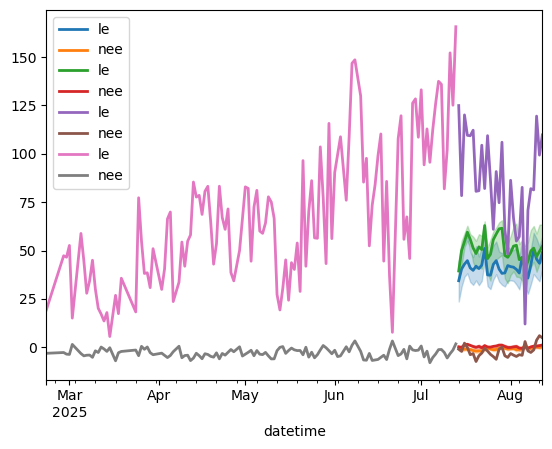

In [83]:
pred_tft30.plot()
pred_tft.plot()
future_target.plot()
target30_segments[-1].plot()

In [71]:
def get_taylor_stats(obs, *models):
    n = len(models)
    
    sdev = np.zeros(n+1)
    crmsd = np.zeros(n+1)
    ccoef = np.zeros(n+1)
    
    for i in range(n):
        stats = sm.taylor_statistics(models[i],obs)
        if i == 0:
            sdev[0:2] = stats['sdev']
            crmsd[0:2] = stats['crmsd']
            ccoef[0:2] = stats['ccoef']
        else:
            sdev[i+1] = stats['sdev'][1]
            crmsd[i+1] = stats['crmsd'][1]
            ccoef[i+1] = stats['ccoef'][1]

    return sdev, crmsd, ccoef

In [84]:
taylor_stats = get_taylor_stats(future_target["le"].to_series(), 
                                pred_tft["le"].mean().to_series(), 
                                pred_tft30["le"].mean().to_series())

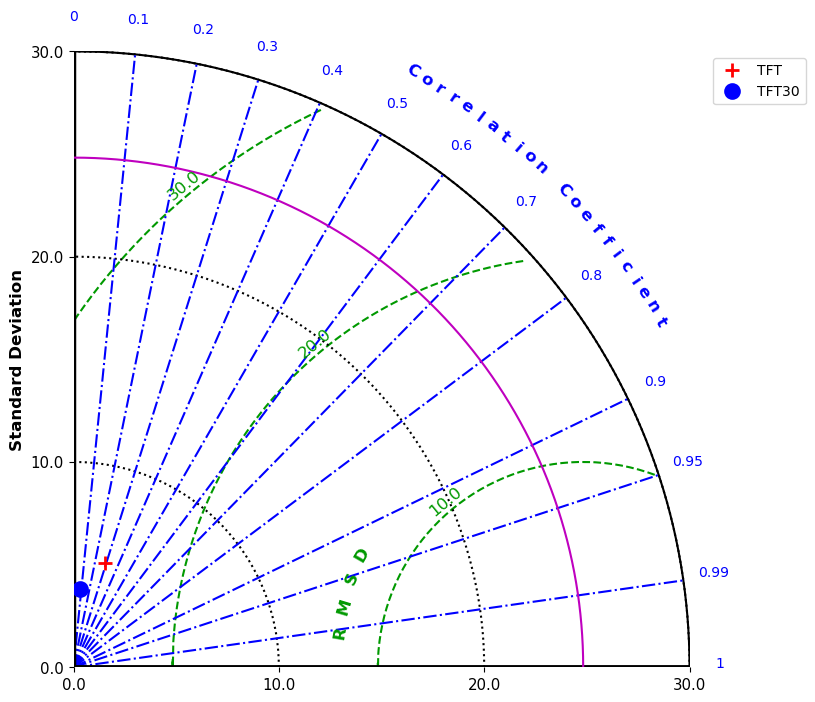

In [85]:
plt.figure(figsize=(8,8))
sm.taylor_diagram(*taylor_stats, styleOBS="-", markerLabel=["Obs","TFT","TFT30"], markerlegend="on")